In [1]:
import pandas as pd
from sankeyflow import Sankey
import matplotlib.pyplot as plt
import json

# Set the default style for the Matplotlib plots
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": "CMU Serif",
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{amsmath}",
        "font.size": 10,
        "font.weight": "normal",
        "figure.titlesize": "medium",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "savefig.dpi": 300,
        "figure.dpi": 150,
        "savefig.bbox": "tight",
    }
)

In [2]:
max_profit_json = json.load(
    open("/Users/htbui/Downloads/DE_results_T_10_delta_5_scen_4_trial_1_inv_1_cap._1_cap.inc._2_max_profit.json")
)
min_cost_json = json.load(
    open("/Users/htbui/Downloads/DE_results_T_10_delta_5_scen_4_trial_1_inv_1_cap._1_cap.inc._2_min_cost.json")
)
base_json = json.load(
    open("/Users/htbui/Downloads/DE_results_T_10_delta_5_scen_4_trial_1_inv_1_cap._1_cap.inc._2_base.json")
)

- $F_{a,t,\tau}$
- $I_{v,t,\omega}$
- $S_{a,t,\omega}$
- $X_{p,t,\omega}$

In [110]:
X_info = min_cost_json["X"]
X_info["PCV"]["GSK"]
# X_info
# vaccines = list(F_info.keys())
# vaccines

{'5': {'4': 0.0, '2': 0.0, '3': 95608.00000000035, '1': 177242.4000000002},
 '4': {'4': 0.0, '2': 0.0, '3': 81634.40000000002, '1': 0.0},
 '6': {'4': 0.0, '2': 58930.0, '3': 0.0, '1': 0.0},
 '7': {'4': 38631.20000000007, '2': 0.0, '3': 0.0, '1': 38631.20000000007},
 '2': {'4': 90705.20000000001,
  '2': 90705.20000000001,
  '3': 90705.20000000001,
  '1': 90705.20000000001},
 '10': {'4': 130574.40000000008,
  '2': 0.0,
  '3': 219107.0,
  '1': 138536.40000000008},
 '9': {'4': 181410.40000000008, '2': 0.0, '3': 0.0, '1': 124286.40000000008},
 '8': {'4': 86895.80000000005, '2': 0.0, '3': 0.0, '1': 136057.80000000005},
 '3': {'4': 89563.79999999978,
  '2': 89563.79999999981,
  '3': 89563.79999999964,
  '1': 89563.79999999981},
 '1': {'4': 6797.599999999977,
  '2': 6797.599999999977,
  '3': 6797.599999999977,
  '1': 6797.599999999977}}

In [33]:
F_info["PCV"]

{'5': {'5': 0.0, '6': 0.0, '7': 0.0, '9': -0.0, '8': 0.0},
 '4': {'5': 0.0, '4': 0.0, '6': 1.0, '7': 0.0, '8': -0.0},
 '6': {'6': 0.0, '7': 0.0, '10': -0.0, '9': 0.0, '8': 1.0},
 '7': {'7': 0.0, '10': 0.0, '9': 0.0, '8': 0.0},
 '2': {'5': 0.0, '4': 0.0, '6': 0.0, '2': 0.0, '3': 0.0},
 '10': {'10': 1.0},
 '9': {'10': 0.0, '9': 1.0},
 '8': {'10': 0.0, '9': 0.0, '8': 0.0},
 '3': {'5': 0.0, '4': 0.0, '6': 0.0, '7': 0.0, '3': 0.0},
 '1': {'5': 0.0, '4': 0.0, '2': 0.0, '3': 1.0, '1': 0.0}}

In [15]:
def extract_F(json_file: dict, file_name: str, verbose: bool = True, threshold: float = 1e-10) -> pd.DataFrame:
    lst: list = []
    F_info = json_file["F"]
    for vax, vax_info in F_info.items():
        for tau, tau_info in vax_info.items():
            for scenario, value in tau_info.items():
                if value > threshold:
                    lst.append((file_name, int(scenario), vax, int(tau), float(value)))
    df = pd.DataFrame(lst, columns=["file_name", "scenario", "vaccine", "tau", "value"])
    df = df.sort_values(by=["scenario", "vaccine", "tau"]).reset_index(drop=True)
    (
        print(
            f"- Extracted {file_name} data: {df.shape} with {df['scenario'].nunique()} scenarios: {list(df['scenario'].unique())}"
        )
        if verbose
        else None
    )
    return df


def extract_X(json_file: dict, file_name: str, verbose: bool = True, threshold: float = 1e-10) -> pd.DataFrame:
    lst: list = []
    X_info = json_file["X"]
    for vax, vax_info in X_info.items():
        for producer, producer_info in vax_info.items():
            for tau, tau_info in producer_info.items():
                for scenario, value in tau_info.items():
                    if value > threshold:
                        lst.append((file_name, int(scenario), vax, producer, int(tau), float(value)))
    df = pd.DataFrame(lst, columns=["file_name", "scenario", "vaccine", "producer", "tau", f"value"])
    df = df.sort_values(by=["scenario", "vaccine", "producer", "tau"]).reset_index(drop=True)
    (
        print(
            f"- Extracted {file_name} data: {df.shape} with {df['scenario'].nunique()} scenarios: {list(df['scenario'].unique())}"
        )
        if verbose
        else None
    )
    return df


max_profit_F_df = extract_F(max_profit_json, "max_profit")
min_cost_F_df = extract_F(min_cost_json, "min_cost")
base_json_F_df = extract_F(base_json, "base")

max_profit_X_df = extract_X(max_profit_json, "max_profit")
min_cost_X_df = extract_X(min_cost_json, "min_cost")
base_json_X_df = extract_X(base_json, "base")

- Extracted max_profit data: (59, 5) with 7 scenarios: [1, 3, 5, 6, 8, 9, 10]
- Extracted min_cost data: (35, 5) with 5 scenarios: [1, 3, 5, 6, 10]
- Extracted base data: (35, 5) with 5 scenarios: [1, 3, 5, 6, 10]
- Extracted max_profit data: (1140, 6) with 4 scenarios: [1, 2, 3, 4]
- Extracted min_cost data: (1026, 6) with 4 scenarios: [1, 2, 3, 4]
- Extracted base data: (1118, 6) with 4 scenarios: [1, 2, 3, 4]


In [16]:
max_profit_X_df

,file_name,scenario,vaccine,producer,tau,value
0,max_profit,1,DT,BB_NCIPD,1,39224.0
1,max_profit,1,DT,BB_NCIPD,2,39224.0
2,max_profit,1,DT,BB_NCIPD,3,39224.0
3,max_profit,1,DT,BB_NCIPD,4,39224.0
4,max_profit,1,DT,BB_NCIPD,5,39224.0
...,...,...,...,...,...,...
1135,max_profit,4,Td,BB_NCIPD,6,39224.0
1136,max_profit,4,Td,BB_NCIPD,7,39224.0
1137,max_profit,4,Td,BB_NCIPD,8,39224.0
1138,max_profit,4,Td,BB_NCIPD,9,39224.0


In [23]:
def check_similarity(
    left_df: pd.DataFrame, right_df: pd.DataFrame, on_cols: list, left_scen=None, right_scen=None, verbose: bool = True
) -> tuple:
    left_df = left_df[left_df["scenario"] == left_scen].reset_index(drop=True) if left_scen else left_df
    left_name = left_df["file_name"].unique()[0]
    left_df.drop("file_name", axis=1, inplace=True)
    right_df = right_df[right_df["scenario"] == right_scen].reset_index(drop=True) if right_scen else right_df
    right_name = right_df["file_name"].unique()[0]
    right_df.drop("file_name", axis=1, inplace=True)

    # Check if the two dataframes are the same
    check_df = (
        pd.merge(
            left_df,
            right_df,
            on=on_cols,
            how="outer",
            suffixes=(f"_{left_name}", f"_{right_name}"),
            indicator=True,
        )
        .sort_values(by=on_cols)
        .reset_index(drop=True)
    )
    # Get the rows that are in both dataframes
    both_df = check_df[check_df["_merge"] == "both"]
    # Get the rows only in the left dataframe
    left_only = check_df[check_df["_merge"] == "left_only"]
    # Get the rows only in the right dataframe
    right_only = check_df[check_df["_merge"] == "right_only"]
    if verbose:
        (
            print(f"- Check similarity between scenario {left_scen} for left and {right_scen} for right:")
            if left_scen and right_scen
            else print("- Check similarity:")
        )
        print(f"  - Both: {both_df.shape[0]} rows")
        print(f"  - Left only: {left_only.shape[0]} rows")
        print(f"  - Right only: {right_only.shape[0]} rows")

    for scenario, scenario_info in check_df.groupby("scenario"):
        merge_options = scenario_info["_merge"].unique()
        if len(merge_options) > 1 and verbose:
            print(f"  - Different values in scenario {scenario}")

    return (both_df, left_only, right_only, check_df)


print(f"- Check F dataframes:")
_, _, _, check_F_df = check_similarity(
    max_profit_F_df, min_cost_F_df, on_cols=["scenario", "vaccine", "tau", "value"], left_scen=1, right_scen=1
)
print(f"\n- Check X dataframes:")
_, _, _, check_X_df = check_similarity(
    max_profit_X_df,
    min_cost_X_df,
    on_cols=["scenario", "vaccine", "producer", "tau", "value"],
    left_scen=1,
    right_scen=1,
)

- Check F dataframes:
- Check similarity between scenario 1 for left and 1 for right:
  - Both: 7 rows
  - Left only: 0 rows
  - Right only: 0 rows

- Check X dataframes:
- Check similarity between scenario 1 for left and 1 for right:
  - Both: 119 rows
  - Left only: 166 rows
  - Right only: 185 rows
  - Different values in scenario 1


In [31]:
check_X_df[check_X_df["scenario"] == 1]

,scenario,vaccine,producer,tau,value,_merge
0,1,DT,BB_NCIPD,1,7844.8,right_only
1,1,DT,BB_NCIPD,1,39224.0,left_only
2,1,DT,BB_NCIPD,2,15689.6,right_only
3,1,DT,BB_NCIPD,2,39224.0,left_only
4,1,DT,BB_NCIPD,3,23534.4,right_only
...,...,...,...,...,...,...
465,1,Td,Serum_Institute,5,84633.0,right_only
466,1,Td,Serum_Institute,7,587114.0,right_only
467,1,Td,Serum_Institute,8,587114.0,right_only
468,1,Td,Serum_Institute,9,587114.0,right_only


In [28]:
a = max_profit_X_df[(max_profit_X_df["scenario"] == 1) & (max_profit_X_df["vaccine"] == "DT")].reset_index(drop=True)
b = a.groupby(["tau"]).agg({"value": "sum"}).reset_index()
c = a.groupby(["producer"]).agg({"value": "sum"}).reset_index()
a["flow"] = a.apply(lambda row: (row["producer"], f"$\\tau = {row['tau']}$", round(row["value"], 2)), axis=1)
b["node"] = b.apply(lambda row: [(f"$\\tau = {row['tau'].astype(int)}$", row["value"].round(2))], axis=1)
c["node"] = c.apply(lambda row: [(row["producer"], row["value"])], axis=1)

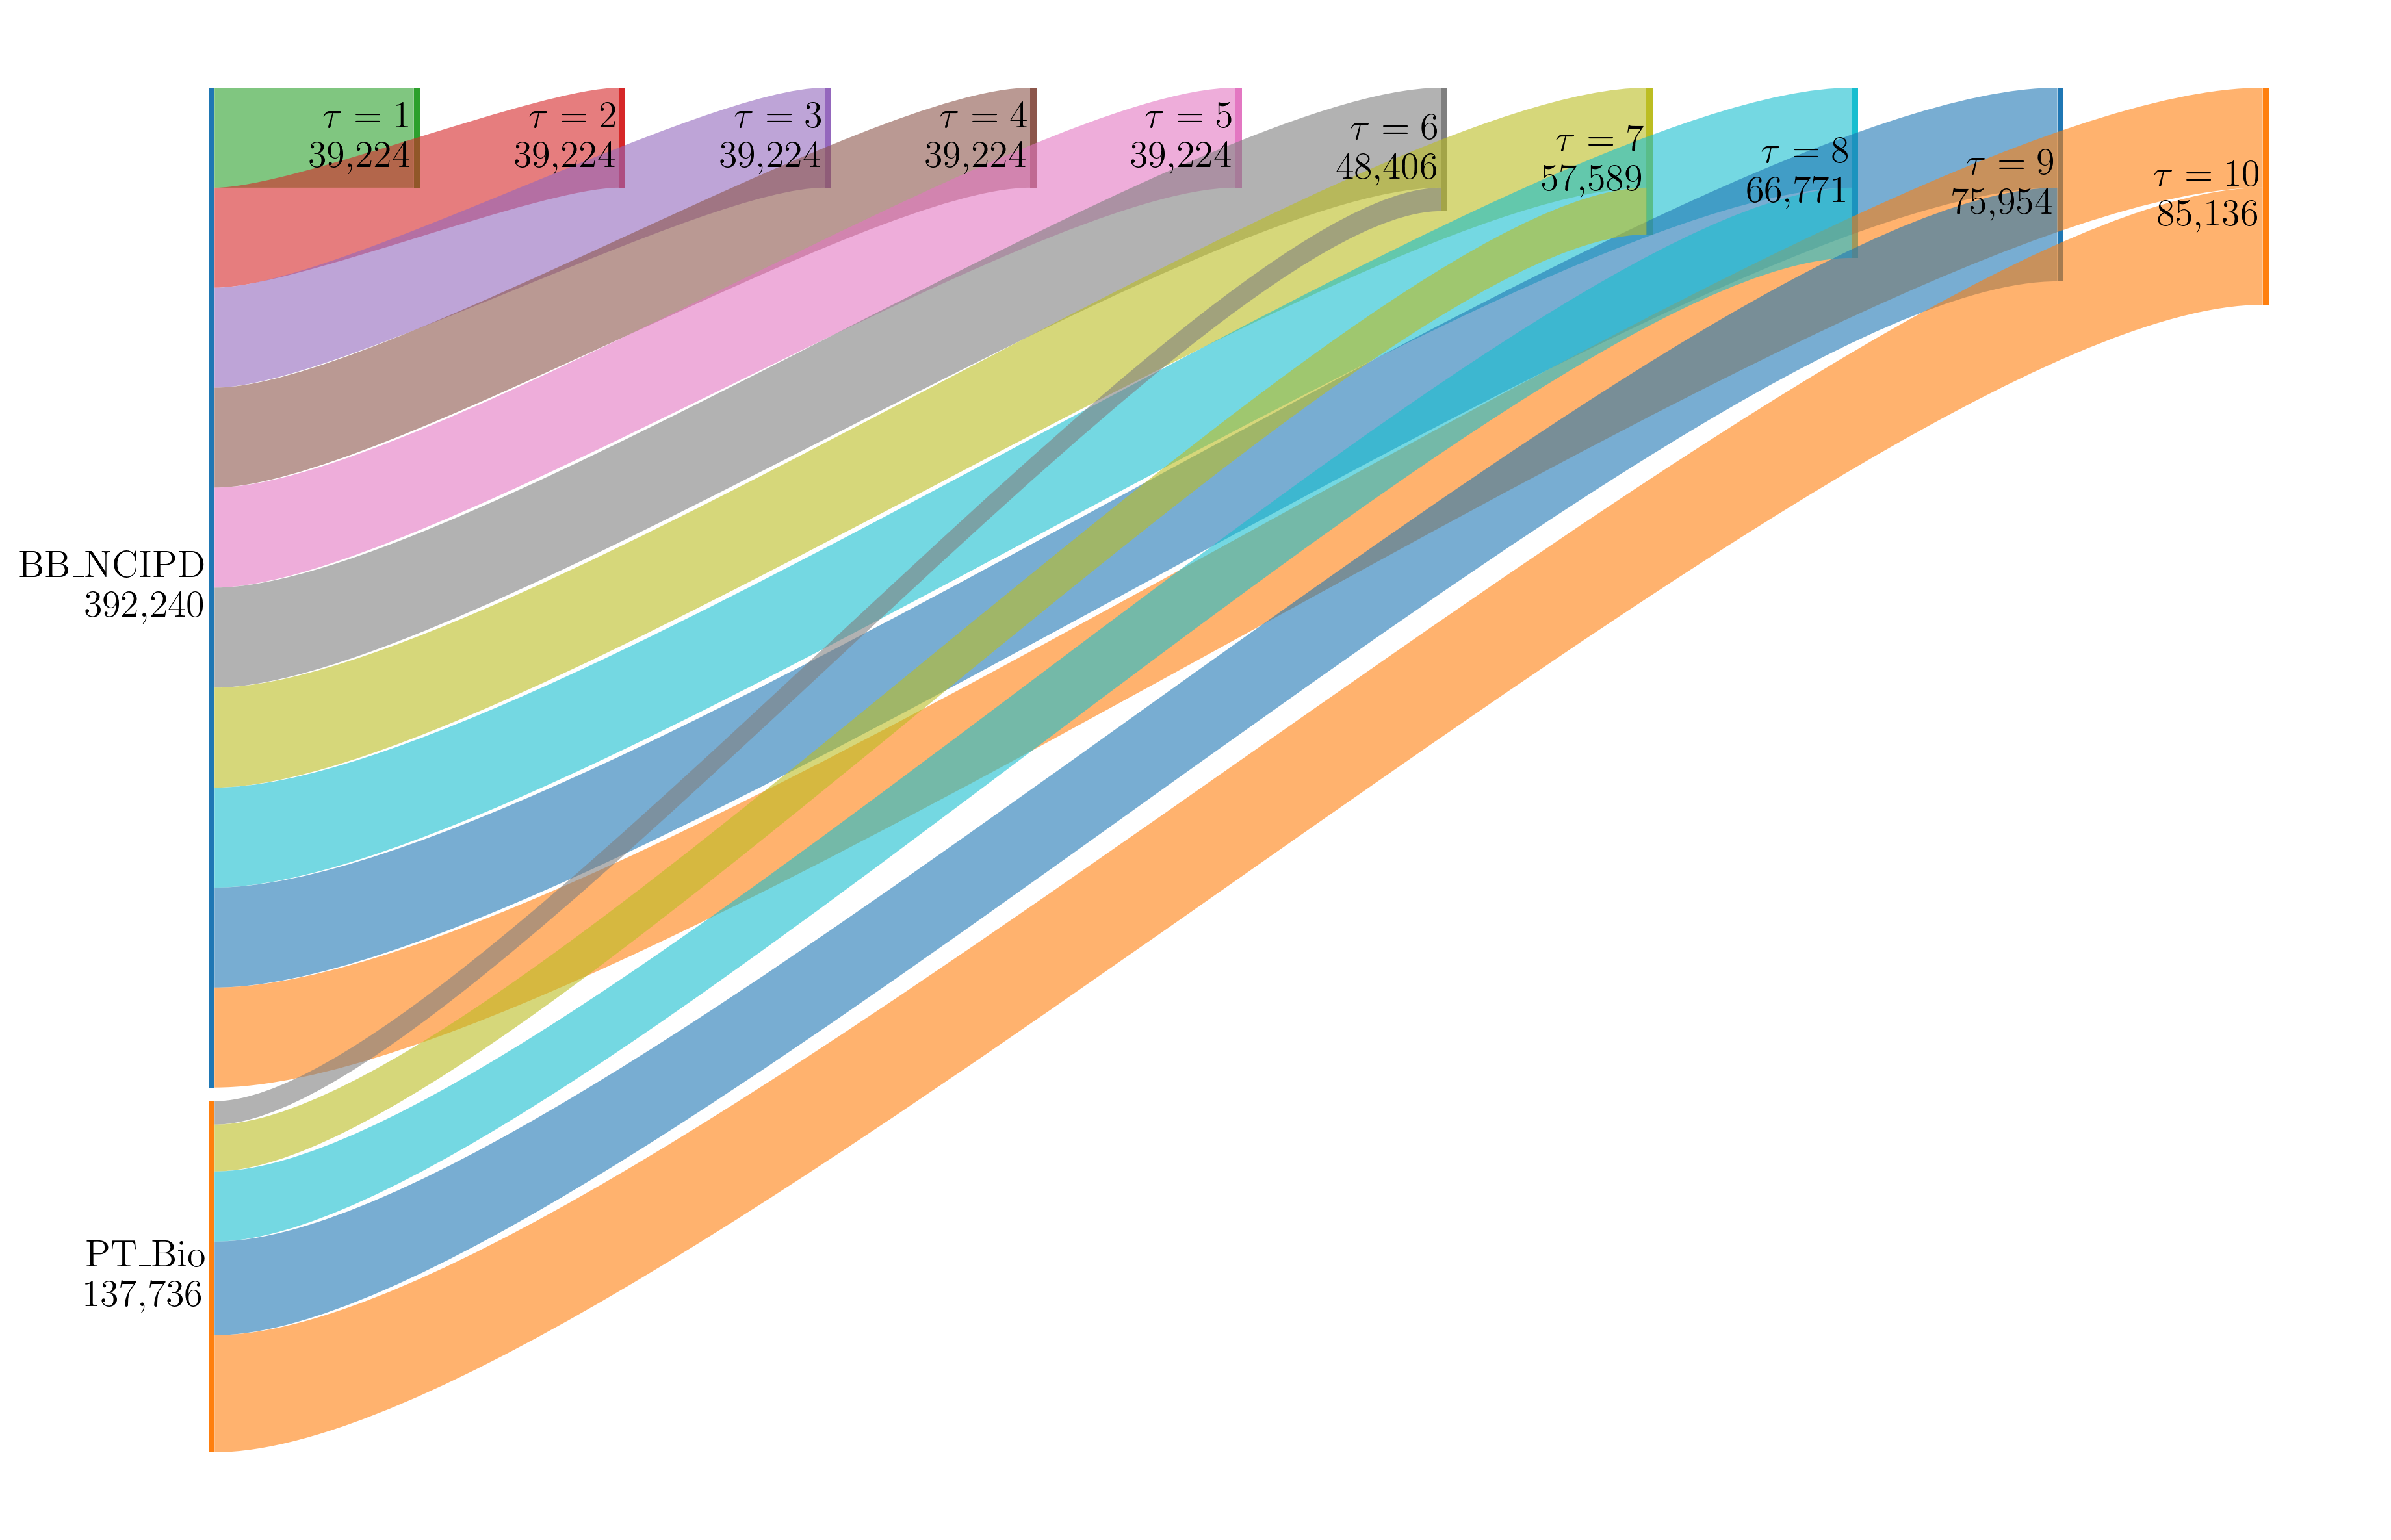

In [8]:
plt.figure(figsize=(15, 10), dpi=300)
nodes = [
    [("BB_NCIPD", 392240.0), ("PT_Bio", 137736.0)],
    [("$\\tau = 1$", 39224.0)],
    [("$\\tau = 2$", 39224.0)],
    [("$\\tau = 3$", 39224.0)],
    [("$\\tau = 4$", 39224.0)],
    [("$\\tau = 5$", 39224.0)],
    [("$\\tau = 6$", 48406.4)],
    [("$\\tau = 7$", 57588.8)],
    [("$\\tau = 8$", 66771.2)],
    [("$\\tau = 9$", 75953.6)],
    [("$\\tau = 10$", 85136.0)],
]
flows = [
    ("BB_NCIPD", "$\\tau = 1$", 39224.0),
    ("BB_NCIPD", "$\\tau = 2$", 39224.0),
    ("BB_NCIPD", "$\\tau = 3$", 39224.0),
    ("BB_NCIPD", "$\\tau = 4$", 39224.0),
    ("BB_NCIPD", "$\\tau = 5$", 39224.0),
    ("BB_NCIPD", "$\\tau = 6$", 39224.0),
    ("BB_NCIPD", "$\\tau = 7$", 39224.0),
    ("BB_NCIPD", "$\\tau = 8$", 39224.0),
    ("BB_NCIPD", "$\\tau = 9$", 39224.0),
    ("BB_NCIPD", "$\\tau = 10$", 39224.0),
    ("PT_Bio", "$\\tau = 6$", 9182.4),
    ("PT_Bio", "$\\tau = 7$", 18364.8),
    ("PT_Bio", "$\\tau = 8$", 27547.2),
    ("PT_Bio", "$\\tau = 9$", 36729.6),
    ("PT_Bio", "$\\tau = 10$", 45912.0),
]

# s = Sankey(
#     flows=flows,
#     nodes=nodes,
#     # cmap=plt.cm.Pastel1,
#     flow_opts=dict(curvature=0.1),
#     flow_color_mode="source",
# )

s = Sankey(
    nodes=nodes,
    flows=flows,
    cmap=plt.cm.tab10,
    # node_opts=dict(label_format="{label}: {value:,}"),
    label_opts=dict(fontsize=6),
    flow_opts=dict(curvature=0.2),
    # flow_color_mode="source",
)
s.draw()
plt.show()